# [Groq](https://groq.com/)
- Groq은 AI 가속을 위한 특별한 칩 'LPU'를 만드는 미국 AI 회사입니다.
- 개발자를 위한 AI 추론 플랫폼으로, 텍스트, 음성, 이미지 AI 모델 등을 제공하고 있습니다.

## [Groq Cloud 가입](https://groq.com/groqcloud)

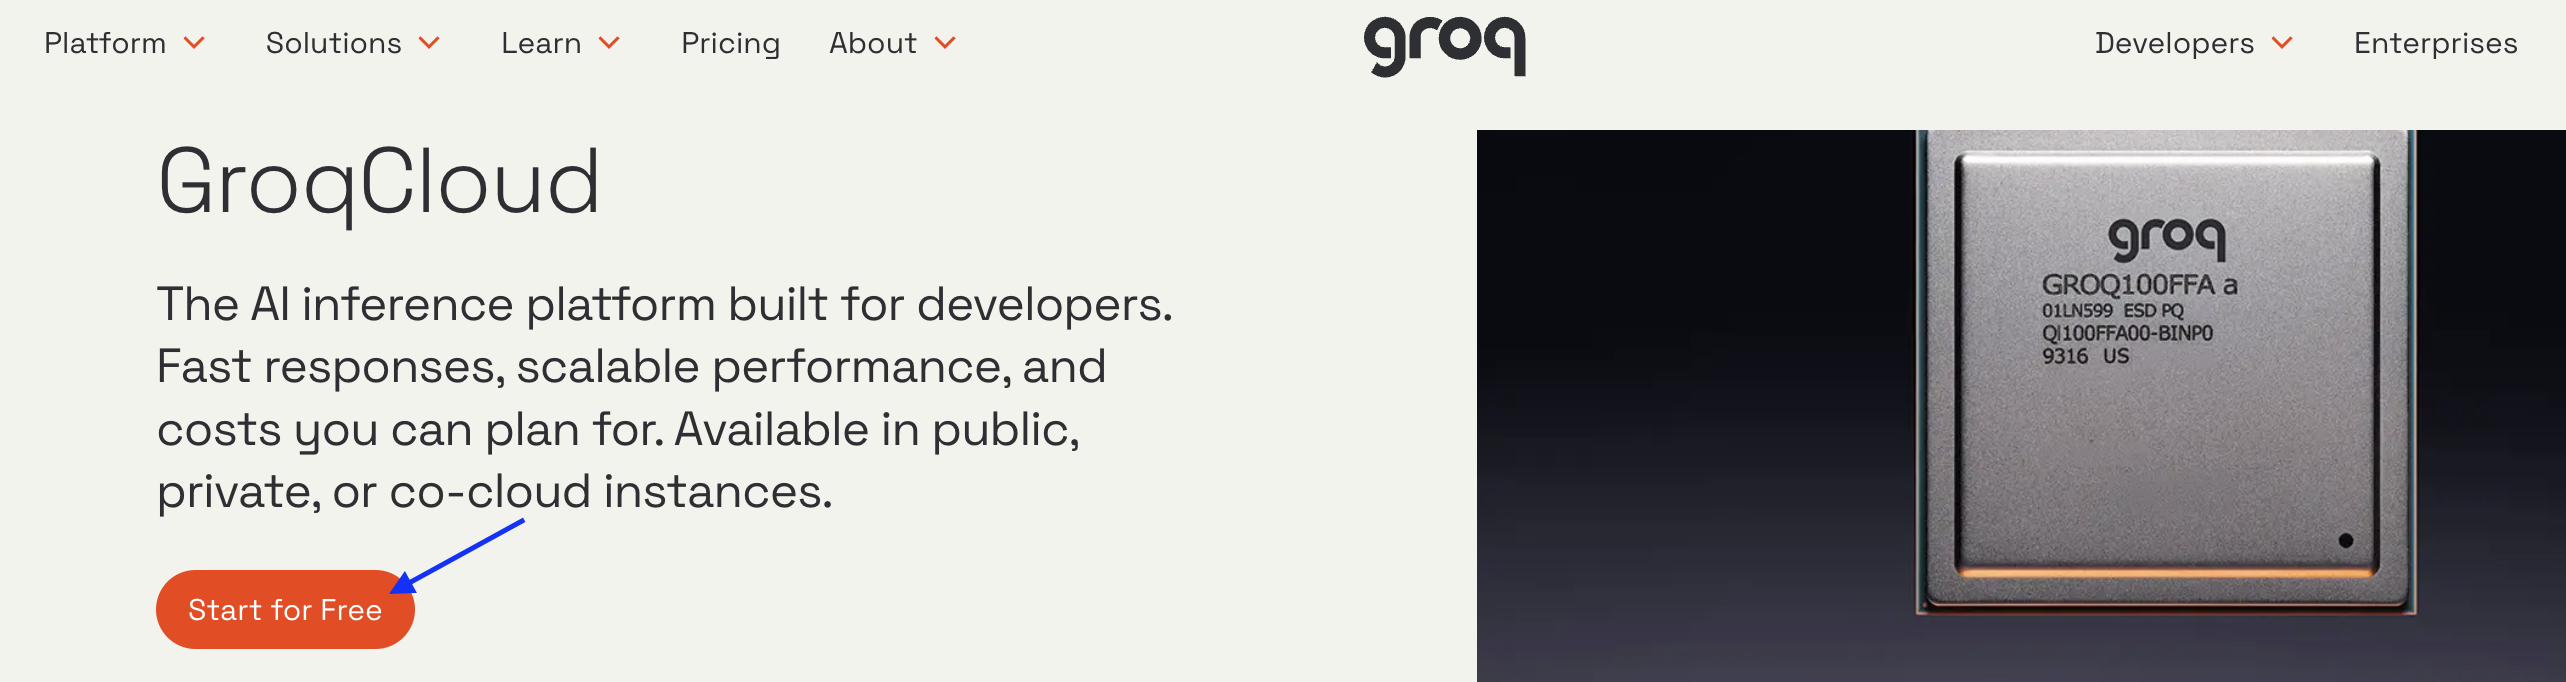

## [Groq Cloud 요금제](https://console.groq.com/settings/billing/plans)
- OpenAI API와는 다르게 Free(무료) 사용이 가능합니다.

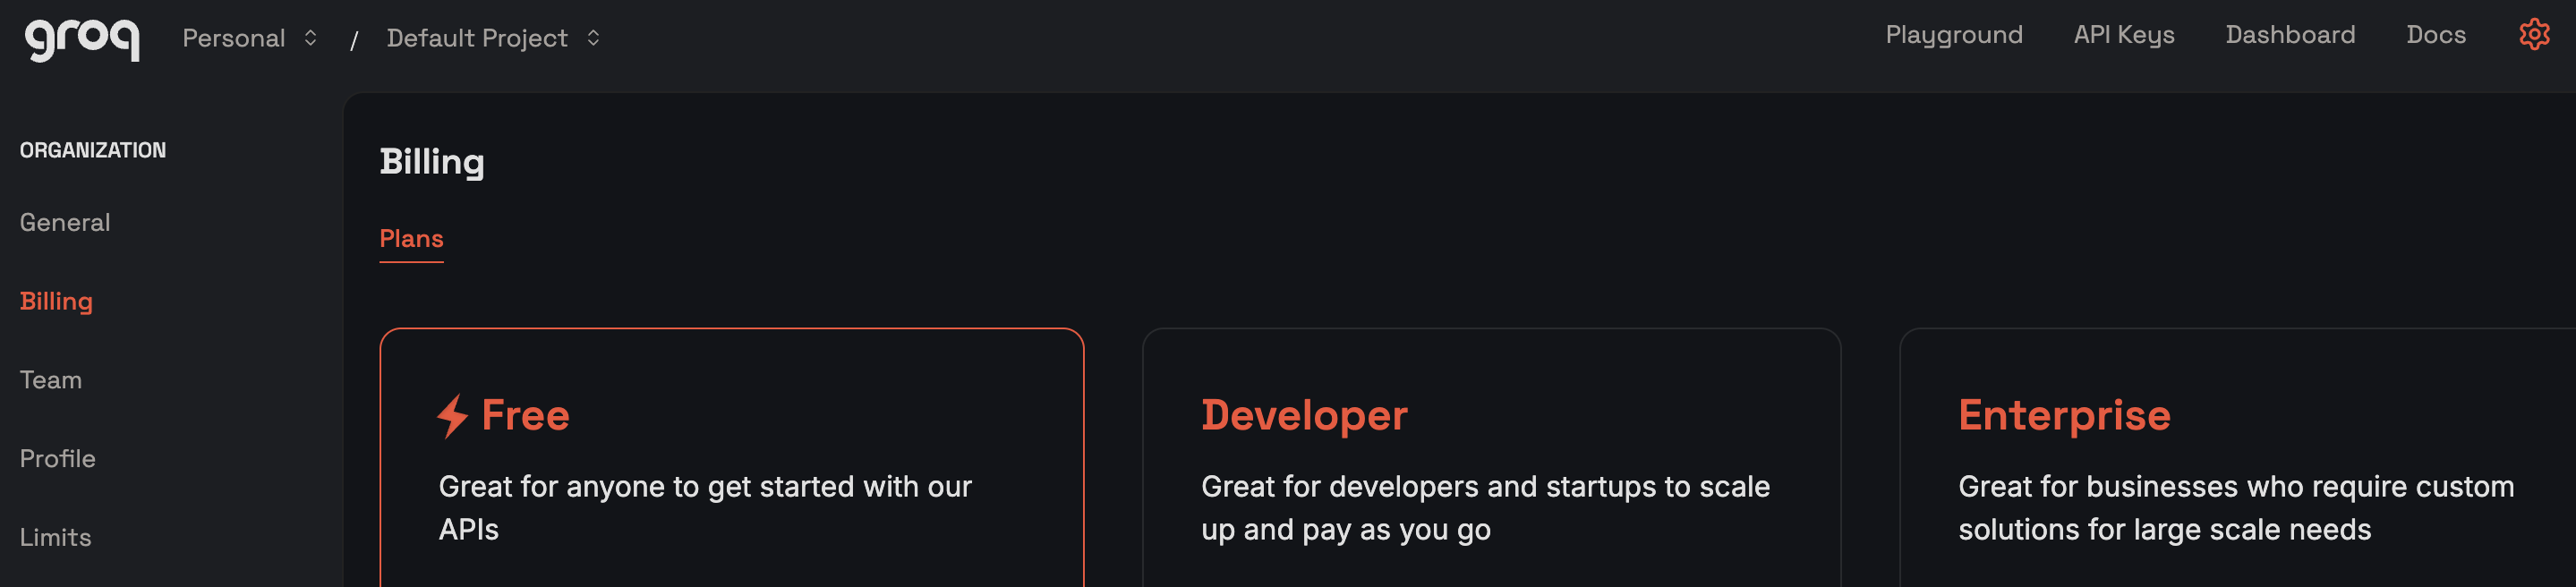

## [Groq API Key](https://console.groq.com/keys)

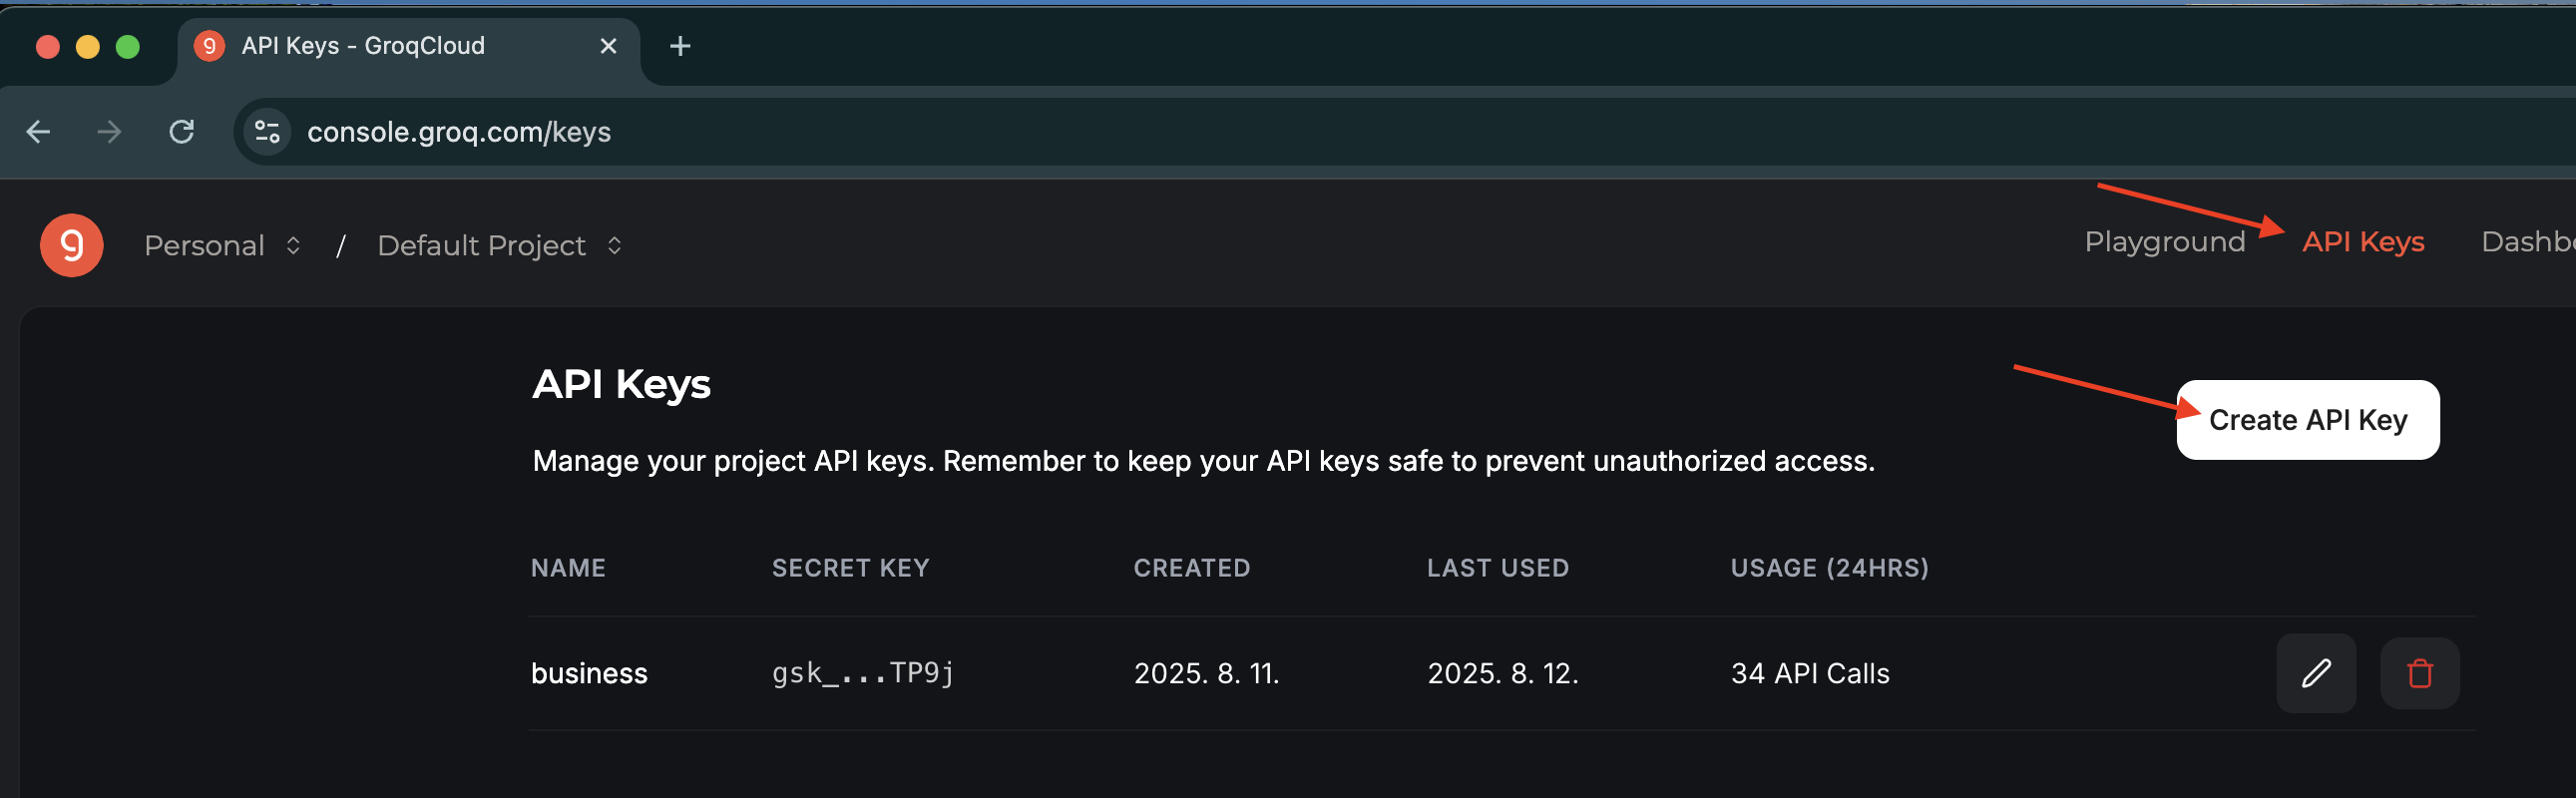

In [1]:
import os 

# 직접 적용 방법
# os.environ["GROQ_API_KEY"] = "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"

In [2]:
from dotenv import load_dotenv

# dotenv 파일에서 환경변수 로드
load_dotenv()

True

In [3]:
# API 키 확인
api_key = os.getenv("GROQ_API_KEY")
if api_key:
    print("GROQ API 키가 설정되었습니다.")
else:
    print("GROQ API 키가 없습니다.")

GROQ API 키가 설정되었습니다.


## [Groq API Models](https://console.groq.com/docs/models)

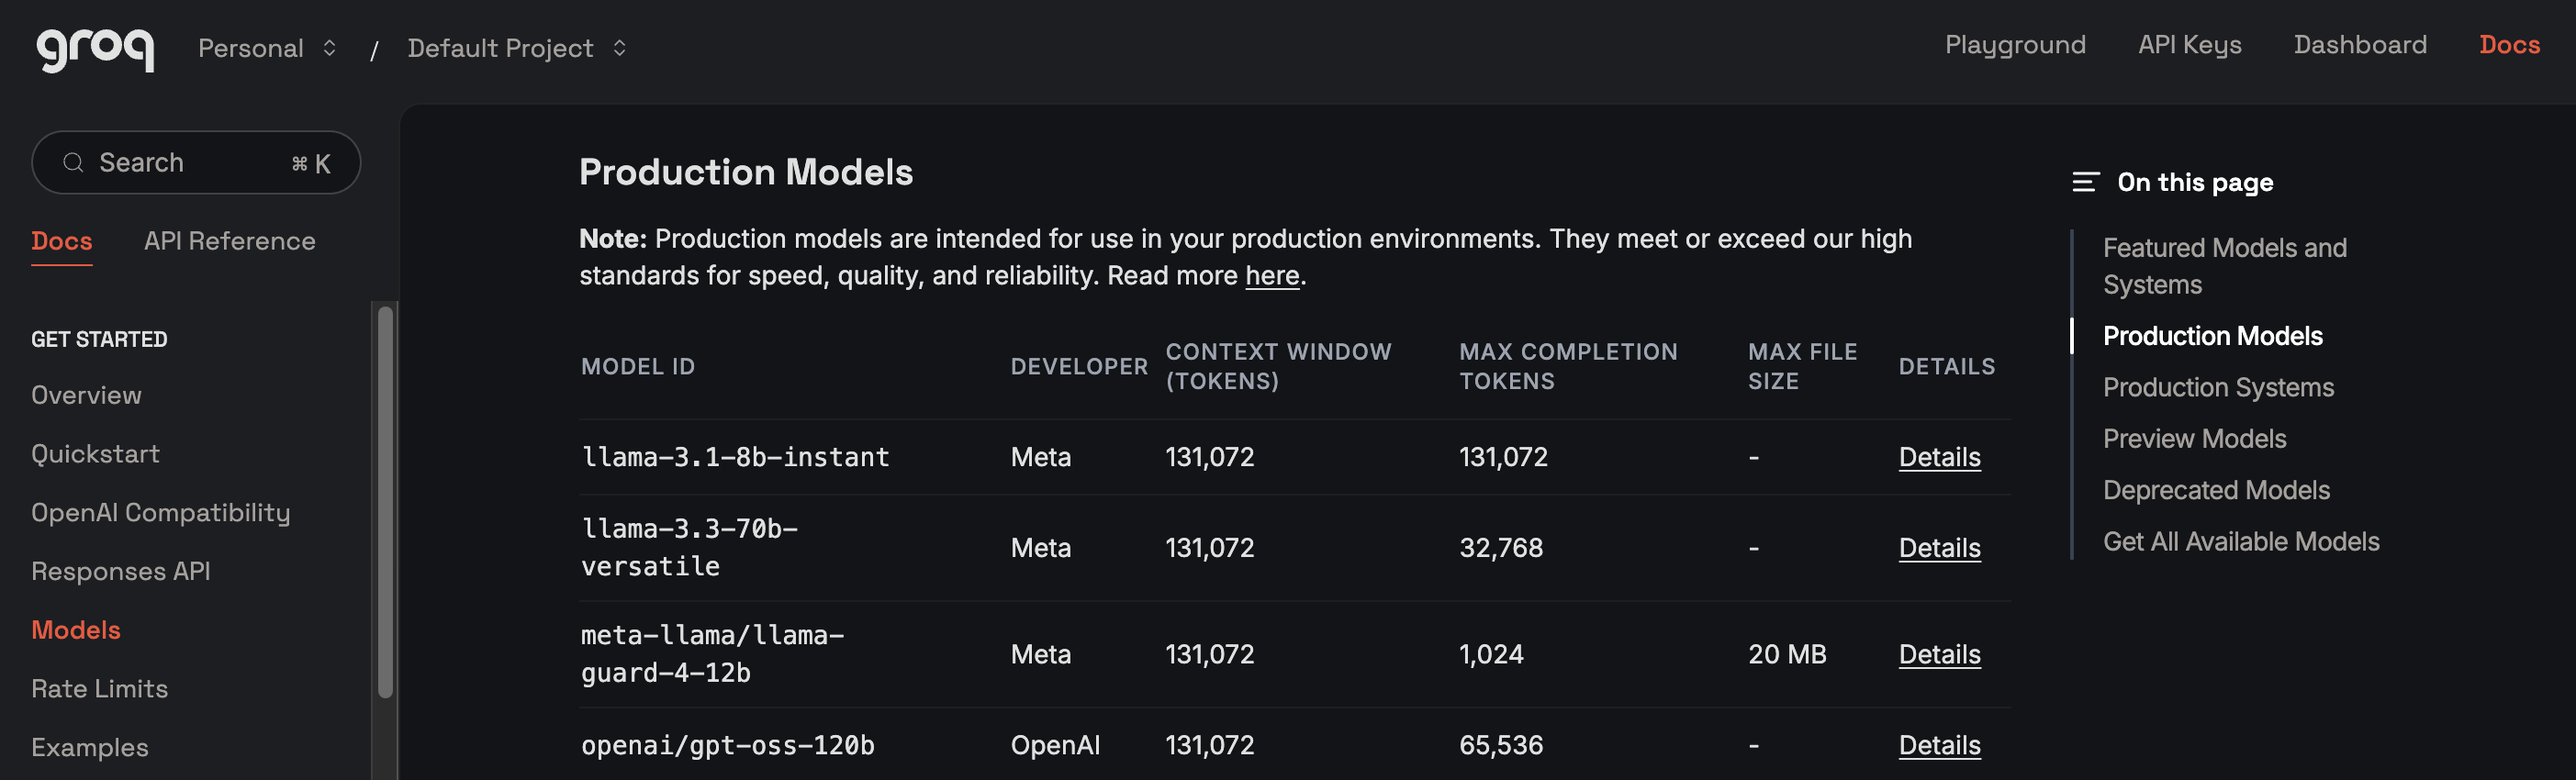

### [주요 파라미터](https://console.groq.com/docs/text-chat)

- 필수 파라미터

| 파라미터 | 설명 | 예시 |
|---------|------|------|
| **messages** | 대화 내용 리스트 (role과 content 포함) | `[{"role": "user", "content": "안녕"}]` |
| **model** | 사용할 모델 ID | `"llama-3.3-70b-versatile"` |

- 선택 파라미터 (중요)

| 파라미터 | 타입 | 기본값 | 설명 |
|---------|------|--------|------|
| **temperature** | 0~2 | 1 | 랜덤성 조절. 낮을수록 일관적, 높을수록 창의적 |
| **max_completion_tokens** | 정수 | - | 생성할 최대 토큰 수 |
| **top_p** | 0~1 | 1 | 핵 샘플링. 0.1이면 상위 10% 확률만 고려 |
| **stream** | true/false | false | 실시간 스트리밍 여부 |
| **stop** | 문자열/배열 | null | 생성 중단 시퀀스 (예: `", 6"`) |

- 고급 파라미터

| 파라미터 | 범위 | 설명 |
|---------|------|------|
| **frequency_penalty** | -2.0~2.0 | 같은 단어 반복 방지 (양수일수록 강함) |
| **presence_penalty** | -2.0~2.0 | 새로운 주제로 유도 (양수일수록 강함) |
| **seed** | 정수 | 결과 재현성을 위한 시드값 |
| **n** | 정수 | 생성할 응답 개수 (현재 1만 지원) |
| **user** | 문자열 | 사용자 식별자 (남용 방지용) |

- 응답 형식

| 파라미터 | 설명 |
|---------|------|
| **response_format** | 응답 형식 지정 (`json_schema`, `json_object` 등) |
| **include_reasoning** | 추론 과정 포함 여부 (일부 모델만 지원) |

- 스트리밍 옵션

| 파라미터 | 설명 |
|---------|------|
| **stream_options** | 스트리밍 응답 옵션 설정 (`stream: true`일 때만) |

# [Langchain with Groq Model](https://docs.langchain.com/oss/python/integrations/providers/groq)
- 대형 언어 모델(Large Language Model)을 LangChain 프레임워크 내에서 사용하기 위한 객체 또는 인터페이스를 말합니다.

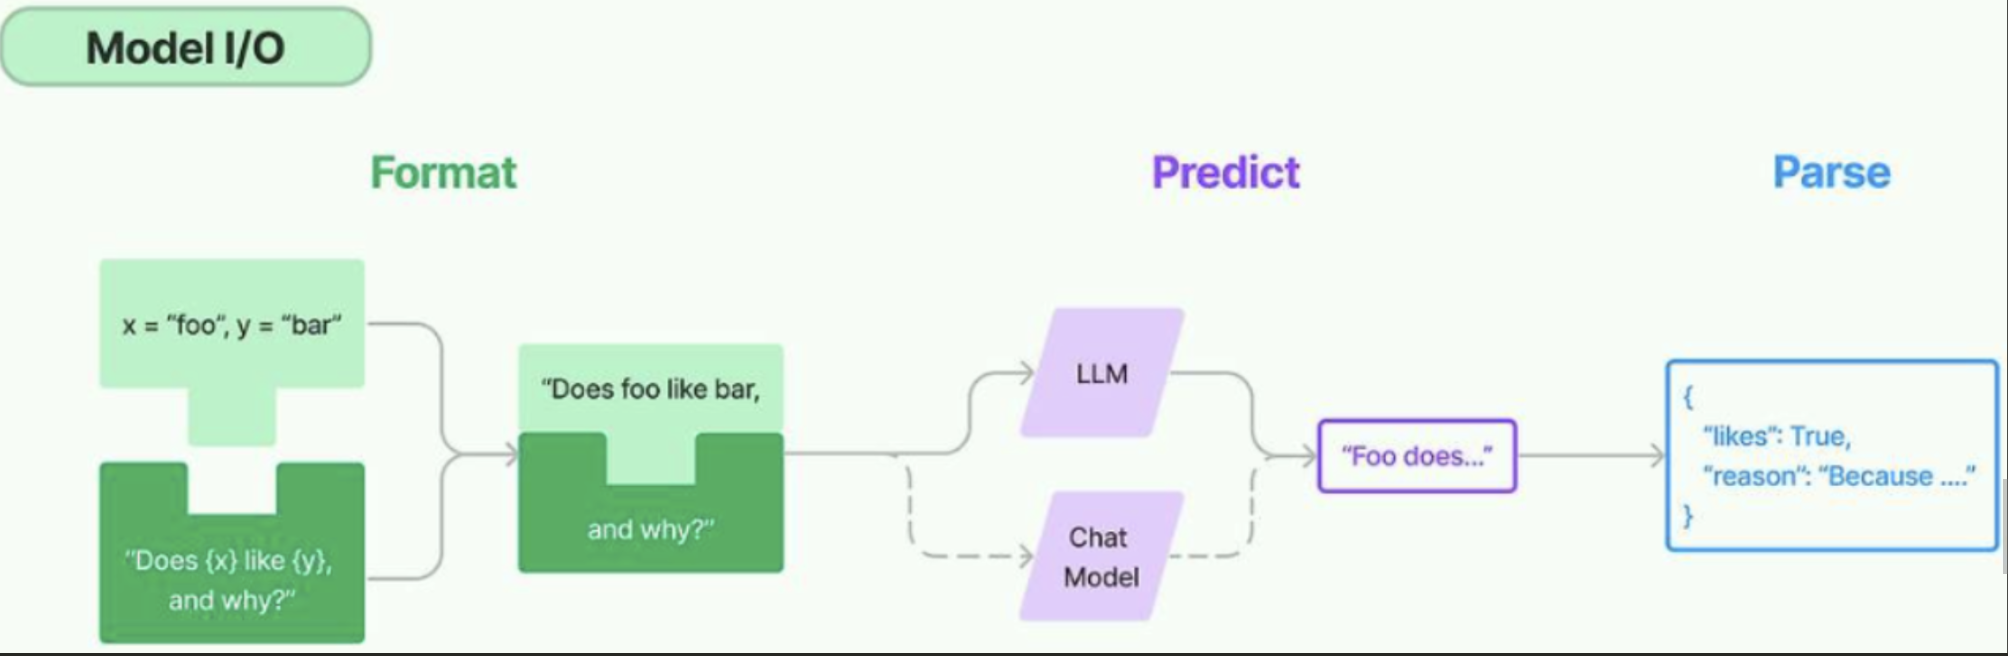

## 창작용 (Creative Writing)

In [4]:
from langchain_groq import ChatGroq

# 1. 창의적인 모델 (Creative Model)
# - temperature 높음 (1.2): 다양하고 창의적인 답변
creative_llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=1.2,
    model_kwargs={
        "top_p":0.9,                     # nucleus sampling (0.8~0.95 권장)
        "frequency_penalty":0.7,         # 반복 억제
        "presence_penalty":0.6,          # 새로운 아이디어 유도
    },
    max_tokens=2000
)

In [5]:
# 사용자 입력에 대한 응답 생성
# response는 AI가 생성한 이야기
response = creative_llm.invoke(
    "시간 여행자가 조선을 방문하는 5문장의 짧은 소설을 써줘."
)

In [6]:
response

AIMessage(content='1. 21세기의 물리학자가 만든 시공간 포털을 통과한 그는 눈앞에 펼쳐진 한옥 골목과 조용한 종소리에 숨을 멈췄다.  \n2. 궁궐의 대문을 지나며 옷차림이 전통 한복인 궁인들이 웃으며 인사했지만, 그는 현대의 스마트 워치를 손목에 찬 채 신중히 주변을 살폈다.  \n3. 시장 거리에서는 김밥 대신 김치와 쌀밥을 파는 노점상이 있었고, 그는 그 맛을 입에 담으며 “역사적 미식 체험”이라 적힌 일기를 적었다.  \n4. 밤이 찾아와 별빛이 비치는 한강변에 서자, 조선 사람들은 별자리 이야기를 나누었고, 그는 그때의 이야기를 미래의 인공지능에게 전해줄 데이터를 수집했다.  \n5. 포털이 다시 열리자, 그는 조선의 따뜻한 눈빛을 뒤로 한 채 현대의 실험실로 돌아와, 과학과 역사가 교차하는 순간을 영원히 기억했다.', additional_kwargs={'reasoning_content': 'The user asks in Korean: "시간 여행자가 조선을 방문하는 5문장의 짧은 소설을 써줘." Means "Write a short story of 5 sentences about a time traveler visiting Joseon." This is allowed. Provide a short story, 5 sentences. No disallowed content. Provide Korean.'}, response_metadata={'token_usage': {'completion_tokens': 332, 'prompt_tokens': 92, 'total_tokens': 424, 'completion_time': 0.684790052, 'prompt_time': 0.003515033, 'queue_time': 0.051092427, 'total_time': 0.688305085}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_1d1727abc9', 'serv

In [7]:
print(response.content)

1. 21세기의 물리학자가 만든 시공간 포털을 통과한 그는 눈앞에 펼쳐진 한옥 골목과 조용한 종소리에 숨을 멈췄다.  
2. 궁궐의 대문을 지나며 옷차림이 전통 한복인 궁인들이 웃으며 인사했지만, 그는 현대의 스마트 워치를 손목에 찬 채 신중히 주변을 살폈다.  
3. 시장 거리에서는 김밥 대신 김치와 쌀밥을 파는 노점상이 있었고, 그는 그 맛을 입에 담으며 “역사적 미식 체험”이라 적힌 일기를 적었다.  
4. 밤이 찾아와 별빛이 비치는 한강변에 서자, 조선 사람들은 별자리 이야기를 나누었고, 그는 그때의 이야기를 미래의 인공지능에게 전해줄 데이터를 수집했다.  
5. 포털이 다시 열리자, 그는 조선의 따뜻한 눈빛을 뒤로 한 채 현대의 실험실로 돌아와, 과학과 역사가 교차하는 순간을 영원히 기억했다.


## 정확한 답변용 (Fact-based)

In [8]:
from langchain_groq import ChatGroq

# 2. 정확한 모델 (Precise Model)
# - temperature 낮음 (0.1): 일관되고 정확한 답변
fact_llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.1,
    model_kwargs={
        "top_p":1.0,                     # nucleus sampling (0.8~0.95 권장)
        "frequency_penalty":0.0,         # 반복 억제
        "presence_penalty":0.0,          # 새로운 아이디어 유도
    },
    max_tokens=2000
)

In [9]:
response = fact_llm.invoke(
    "지구에서 가장 깊은 바다는 어디야?"
)

In [10]:
print(response.content)

지구에서 가장 깊은 바다는 **태평양**에 위치한 **마리아나 해구(Mariana Trench)** 입니다.  

- **가장 깊은 지점**: 챌린저 딥(Challenger Deep)  
- **깊이**: 약 **10,900 미터**(약 35,800 피트) 정도로, 해수면 아래에서 가장 깊은 곳입니다.  

마리아나 해구는 동남아시아(필리핀)와 괌 사이에 위치해 있으며, 그 깊이는 에베레스트 산(약 8,848 미터)보다도 더 깊습니다. 따라서 지구에서 가장 깊은 바다, 즉 가장 깊은 해양 구역은 바로 이 마리아나 해구가 차지하고 있습니다.
